# Project Title : **Geomagnetic activity modeling & forecasting**
# Full name : Mustapha Boulefa


---


# Project Overview
This project models a dataset of 912 monthly observations of the geomagnetic Ap index (1950-2025). The Ap index measures Earth's magnetic field disturbance caused by solar wind with direct consequences for satellites operations, GPS performance, power grid stability, and even natural phenomena such as auroras.


---


## Dataset Overview (GFZ)
The dataset is provided by GFZ German Research Centre for Geosciences
(Potsdam, Germany) and is freely available under the Creative Commons
Attribution 4.0 International (CC BY 4.0) license. It covers the period
January 1950 to December 2025 and was downloaded directly from the GFZ
official portal in the kp1 format. The official data publication is:
Matzka, J., Bronkalla, O., Tornow, K., Elger, K. and Stolle, C., 2021.
Geomagnetic Kp index. V. 1.0. GFZ Data Services,
doi.org/10.5880/Kp.0001.


This dataset contains dataset related to solar and geomagnetic activity, valuable for research in space weather and solar physics, and for time series analysis. It provides the historical daily records of the 3 hour Kp,Ap indices, the Sunspot Number, and the F10.7 measure.


---


# Attributes description
**Kp index :** Dimensionless quasi-logarithmic scale ranging from 0 to 9 (discrete fractional scale), it quantifies the disturbance of earth's horizontal magnetic field caused by solar particle radiation. (measured each 3 hours resulting 8 records/day)

**Ap index :** The linearized version of Kp, on a continuous scale from 0 to 400, each value is the direct conversion of the corresponding Kp value, and the daily Ap is the mean of the 8 values.

**SN (International Sunspot Number) :** A daily count of sunspots visible on the solar disk, it is the primary proxy for the level of solar activity and directly drives the famous ~11-year solar cycle.

**F10.7 (Solar Radio Flux) :** The intensity of solar radio emissions at a wavelength of 10.7 cm (2.8 GHz), measured in solar flux units (sfu, 1 sfu = 10⁻²² W m⁻² Hz⁻¹). It is one of the most reliable continuous proxies for solar activity because it correlates strongly with ultraviolet and X-ray emissions that drive ionospheric changes.

In [229]:
#install all the packages
install.packages("tseries")
install.packages("forecast")
install.packages("dplyr")
install.packages("randtests")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [231]:
library(tseries)
library(dplyr)
library(randtests)
library(forecast)

In [169]:
url <- "https://kp.gfz.de/kpdata?startdate=1950-01-01&enddate=2025-12-31&format=kp1#kpdatadownload-143"
download.file(url, destfile = "GFZ_full_dataset.txt")

if the link doesn't work here is the link to the google drive file :
https://drive.google.com/file/d/1yWfKyaLGLEVr1LADM8vYvAgsrbMT4UMC/view?usp=sharing

In [170]:
data <- read.table("GFZ_full_dataset.txt",
                   header = FALSE)
colnames(data) <- c("Year","Month","Day", "days","days_m","BSR","dB",
                    "Kp1","Kp2","Kp3","Kp4","Kp5","Kp6","Kp7","Kp8",
                    "ap1","ap2","ap3","ap4","ap5","ap6","ap7","ap8",
                    "Ap_daily", "SN_daily","F10.7","F10.7_smooth","Flag")

data$Date <- as.Date(paste(data$Year, data$Month, data$Day, sep="-"))
head(data)
nrow(data)

,Year,Month,Day,days,days_m,BSR,dB,Kp1,Kp2,Kp3,⋯,ap5,ap6,ap7,ap8,Ap_daily,SN_daily,F10.7,F10.7_smooth,Flag,Date
,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<date>
1,1950,1,1,6575,6575.5,1595,24,3.000,2.000,2.333,⋯,4,9,7,6,8,143,152.1,147.0,2,1950-01-01
2,1950,1,2,6576,6576.5,1595,25,3.000,3.333,2.333,⋯,2,3,3,3,7,142,-1.0,-1.0,2,1950-01-02
3,1950,1,3,6577,6577.5,1595,26,1.667,1.333,1.000,⋯,9,3,3,12,6,130,155.2,150.0,2,1950-01-03
4,1950,1,4,6578,6578.5,1595,27,2.000,1.000,2.667,⋯,7,12,15,12,10,119,150.0,145.0,2,1950-01-04
5,1950,1,5,6579,6579.5,1596,1,1.667,1.667,2.000,⋯,7,7,5,5,6,108,153.5,148.4,2,1950-01-05
6,1950,1,6,6580,6580.5,1596,2,2.000,3.667,1.333,⋯,12,15,12,9,11,120,145.6,140.8,2,1950-01-06


[1] 27759

# Columns description :
**Year:** Gregorian calendar year.

**Month:** Gregorian calendar month.

**Day:** Day of the month.

**Days (days):** Days since January 1, 1932, 00:00 UT to the start of the UT day.

**Days Mid (days_m):** Days since January 1, 1932, 00:00 UT to midday of the UT day.

**BSR (BSR):** Bartels solar rotation number.

**Day within BSR (dB):** Day within the Bartels solar rotation.

**Kp1 to Kp8:** Kp index for the eight eighths of the UT day.

**ap1 to ap8:** ap index for the eight eighths of the UT day.

**Ap_daily :** Daily mean ap index.

**SN_daily:** International sunspot number, which counts the number of visible dark spots on the sun.

**F10.7:** Observed solar radio flux at 10.7 cm.

**F10.7_smooth:** Adjusted solar radio flux at 10.7 cm.

In [171]:
summary(data$Ap_daily)
summary(data$SN_daily)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    5.00    9.00   13.29   16.00  280.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   23.00   72.00   91.35  142.00  503.00 

**Ap index :**

- We notice that the values of the dataset fall within the valid range of Ap (0-400).

- Most of the values are low ⇒ quite geomagnetic conditions.

- Mean > Median ⇒ Slight right skewed data.

In [244]:
monthly_data <- data %>%
  group_by(Year, Month) %>%
  summarise(
    SN_avg = mean(SN_daily, na.rm = TRUE),
    Ap_avg = mean(Ap_daily, na.rm = TRUE),
    F10.7_avg = mean(F10.7_smooth[F10.7_smooth > 0], na.rm = TRUE),
    .groups = "drop"
  )

head(monthly_data)
nrow(monthly_data)

Year,Month,SN_avg,Ap_avg,F10.7_avg
<int>,<int>,<dbl>,<dbl>,<dbl>
1950,1,143.8710,11.64516,145.9542
1950,2,134.2500,17.67857,139.8870
1950,3,155.3871,14.19355,136.4115
1950,4,160.6333,18.33333,165.4600
1950,5,150.4516,16.22581,160.5043
1950,6,118.3333,14.16667,132.8227


[1] 912

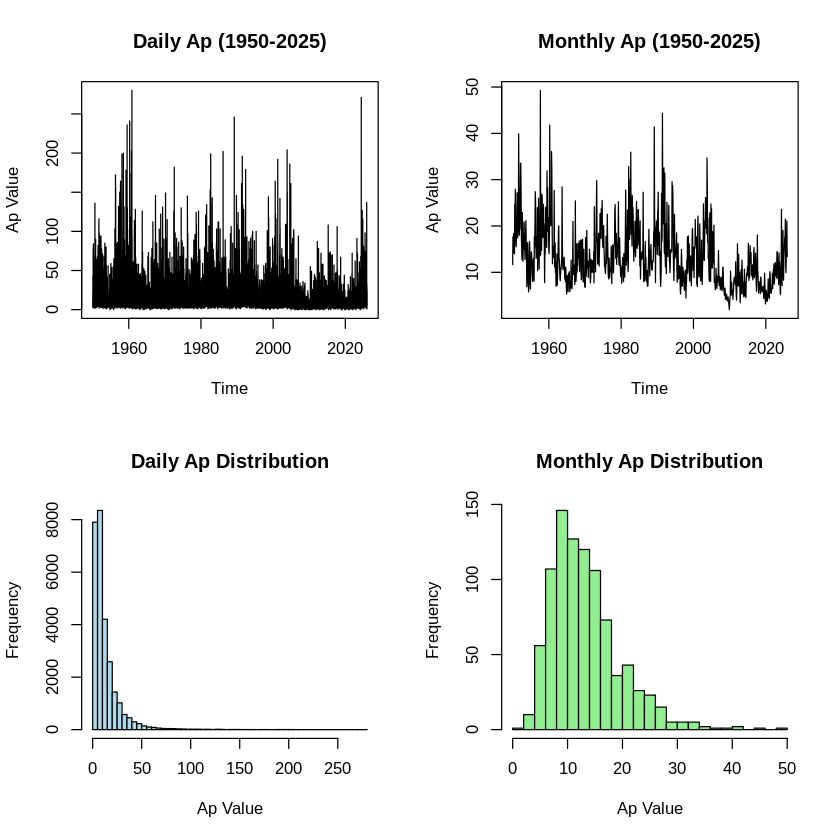

In [245]:
ts_daily = ts(data$Ap_daily, start = c(1950,1), frequency = 365)
ts_ap <- ts(monthly_data$Ap_avg, start = c(1950,1), frequency = 12)
par(mfrow=c(2,2))
plot(ts_daily,
     main="Daily Ap (1950-2025)",
     ylab="Ap Value")

plot(ts_ap,
     main="Monthly Ap (1950-2025)",
     ylab="Ap Value")

hist(data$Ap_daily,
     main="Daily Ap Distribution",
     xlab="Ap Value",
     breaks=50,
     col="lightblue")

hist(monthly_data$Ap_avg,
     main="Monthly Ap Distribution",
     xlab="Ap Value",
     breaks=30,
     col="lightgreen")

**Justification :**
- Daily data is too noisy for trend modeling of individual daily values since it has extreme outliers (single storm reaching 280 Ap) which affects normality and introduces more error in forecasting.
- Daily data tends to be extremely right skewed while the monthly data are more approximately normally distributed.
- Monthly averages captures much better the pattern of the solar cycles (11-year period), with reducing the short-term noise.

In [246]:
summary(monthly_data$Ap_avg)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.935   8.726  12.138  13.297  16.258  49.267 

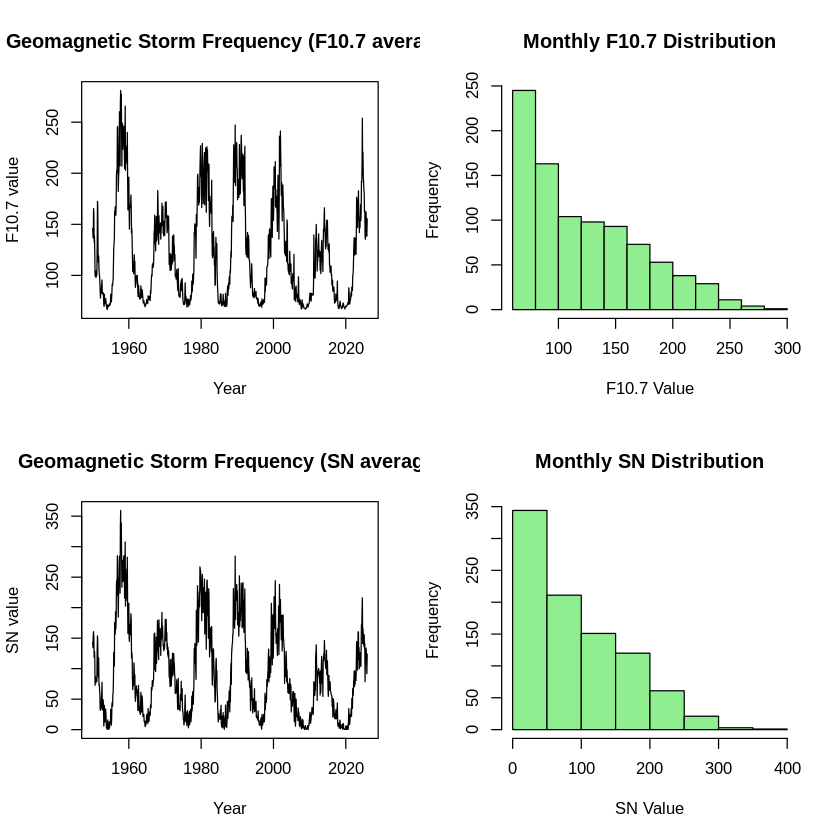

In [247]:
ts_f <- ts(monthly_data$F10.7_avg, start = c(1950,1), frequency = 12)
ts_sn <- ts(monthly_data$SN_avg, start = c(1950, 1), frequency = 12)
par(mfrow = c(2,2))
plot(ts_f,
     main = "Geomagnetic Storm Frequency (F10.7 average)",
     xlab = "Year",
     ylab = "F10.7 value")
hist(monthly_data$F10.7_avg,
     main="Monthly F10.7 Distribution",
     xlab="F10.7 Value",
     col="lightgreen")

plot(ts_sn,
     main = "Geomagnetic Storm Frequency (SN average)",
     xlab = "Year",
     ylab = "SN value")
hist(monthly_data$SN_avg,
     main="Monthly SN Distribution",
     xlab="SN Value",
     col="lightgreen")

**Observation :**
- We notice the correlation between the F10.7 and sunspot numbers, both are proxies of solar magnetic activity (follow the same 11 year solar cycle) where periods of high solar activity increase radio emission (F10.7) and the number of dark spots on the sun (SN).

**Note :**
- The Ap is the measure of the Earth's geomagnetic response to the solar activity, reflecting disturbances in the Earth's magnetic field caused by the geomagnetic storms.

Warning message in adf.test(ts_ap):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_ap
Dickey-Fuller = -5.2352, Lag order = 9, p-value = 0.01
alternative hypothesis: stationary


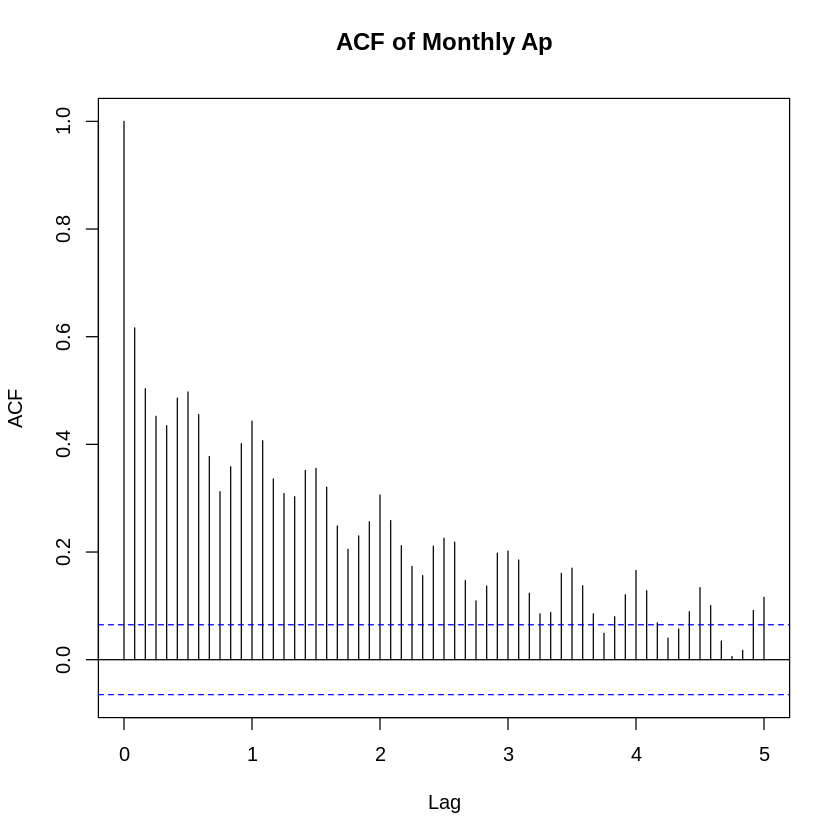

In [248]:
adf.test(ts_ap)
acf(ts_ap, lag.max = 60, main = "ACF of Monthly Ap")

**Observations :**
- p-value = 0.01 < 0.05 ⇒ we reject H₀ ⇒ The time series is stationary (no need for differencing).
- ACF exhibits significant seasonal autocorrelation at the lag k=1 revealing seasonal dependence with 12-months periodicity (meaning January's Ap relates to last January's Ap, ...etc) most likely caused by the Earth's orbital position and geomagnetic effect.
- ACF decays slowly approaching zero, reflecting the long memory of solar activity cycles.

**Conclusion :**
The stationarity of the time series is confirmed with the ADF test (no regular differencing required) but exhibits a significant seasonal autocorrelation at k=1 which might require seasonal differencing.

In [249]:
auto_fit <- auto.arima(ts_ap, stepwise = FALSE, approximation = FALSE)
summary(auto_fit)

Series: ts_ap 
ARIMA(1,1,1)(2,0,0)[12] 

Coefficients:
         ar1      ma1    sar1   sar2
      0.2519  -0.8540  0.1087  0.107
s.e.  0.0454   0.0272  0.0331  0.034

sigma^2 = 21.93:  log likelihood = -2697.74
AIC=5405.49   AICc=5405.56   BIC=5429.56

Training set error measures:
                      ME     RMSE      MAE       MPE     MAPE      MASE
Training set 0.009140817 4.669709 3.240933 -8.435172 25.35164 0.6737872
                     ACF1
Training set -0.003024922

**Observation :**
auto arima suggested ARIMA(1,1,1)(2,0,0)[12] but since the ADF showed that the series are stationary then d=0 so no differencing is needed, so we should try some different combinations for the models and diagnose them using the AIC and BIC.

In [250]:
fit1 <- arima(ts_ap, order = c(1,0,1), seasonal = list(order = c(1,0,1), period = 12))
fit2 <- arima(ts_ap, order = c(2,0,1), seasonal = list(order = c(1,0,1), period = 12))
fit3 <- arima(ts_ap, order = c(2,0,0), seasonal = list(order = c(1,0,1), period = 12))
fit4 <- arima(ts_ap, order = c(1,0,1), seasonal = list(order = c(2,0,0), period = 12))

AIC(fit1, fit2, fit3, fit4)
BIC(fit1, fit2, fit3, fit4)

,df,AIC
,<dbl>,<dbl>
fit1,6,5362.574
fit2,7,5357.759
fit3,6,5412.574
fit4,6,5410.927


,df,BIC
,<dbl>,<dbl>
fit1,6,5391.468
fit2,7,5391.469
fit3,6,5441.468
fit4,6,5439.820


**Observation :** We notice that fit2 achieved the lowest AIC and BIC, which even outperformed the auto arima's suggested model ⇒ stationarity test guides the choice of differencing leading to a better model.

In [251]:
best_fit <- fit2
res <- residuals(best_fit)

In [252]:
runs.test(res)


	Runs Test

data:  res
statistic = -3.0481, runs = 411, n1 = 456, n2 = 456, n = 912, p-value =
0.002303
alternative hypothesis: nonrandomness


**Observation :** Residuals are not fully random since there is some remaining non-random structure (p < 0.05), which might be caused by the irregular solar cycle activity that a linear model can't fully capture.

In [253]:
Box.test(res,lag = 20, type = "Ljung-Box", fitdf = length(best_fit$coef))
shapiro.test(res)


	Box-Ljung test

data:  res
X-squared = 15.302, df = 14, p-value = 0.3578



	Shapiro-Wilk normality test

data:  res
W = 0.89485, p-value < 2.2e-16


**Observations :**
- **Ljnug-Box :** (since p > 0.05) no significant autocorrelation remaining in residuals, meaning the model captured the temporal dependence structure well.
- **Shapiro-Wilk :** (since p < 2.2e-16) normality assumption is rejected, which is most likely caused by extreme geomagnetic storms producing heavy tailed residuals. (n=912)

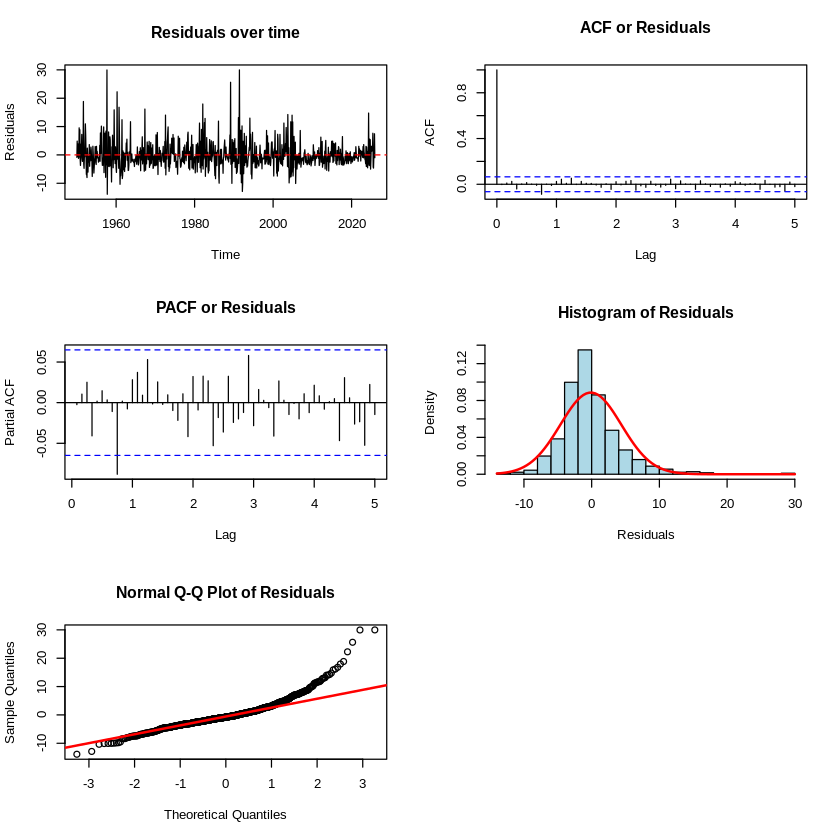

In [254]:
par(mfrow = c(3,2))

plot(res, main = "Residuals over time", ylab = "Residuals")
abline(h=0, col = "red", lty = 2)

acf(res, lag.max = 60, main = "ACF or Residuals")

pacf(res, lag.max = 60, main = "PACF or Residuals")

hist(res, breaks = 30, main = "Histogram of Residuals", xlab = "Residuals",probability = TRUE, col = "lightblue")
curve(dnorm(x, mean = mean(res), sd = sd(res)), add = TRUE, col = "red", lwd = 2)

qqnorm(res, main = "Normal Q-Q Plot of Residuals")
qqline(res, col = "red", lwd = 2)

**Observations :**
- Residuals over time centered at zero.
- The variance is larger in early decades than recent years.
- ACF of residuals shows that all spikes are within the blue bands : no remaining autocorrelation.
- PACF of residuals shows that most spikes are within the blue bands : no remaining partial autocorrelation. (except that one spike but negligible because of Ljung-Box test).
- Histogram approximately bell-shaped and symmetric around zero, but with a slight right tail due to extreme storms that can't be ignored.
- Q-Q plot shows a good fit in the center but both tails deviate confirming non-normality from extreme values.

In [255]:
ts_train <- window(ts_ap, start = c(1950,1), end = c(2023,12))
ts_test  <- window(ts_ap, start = c(2024,1), end = c(2025,12))

In [256]:
fit_final <- arima(ts_train, order = c(2,0,1),
                   seasonal = list(order = c(1,0,1), period = 12))
fcast <- forecast(fit_final, h = 24, level = c(80, 95))

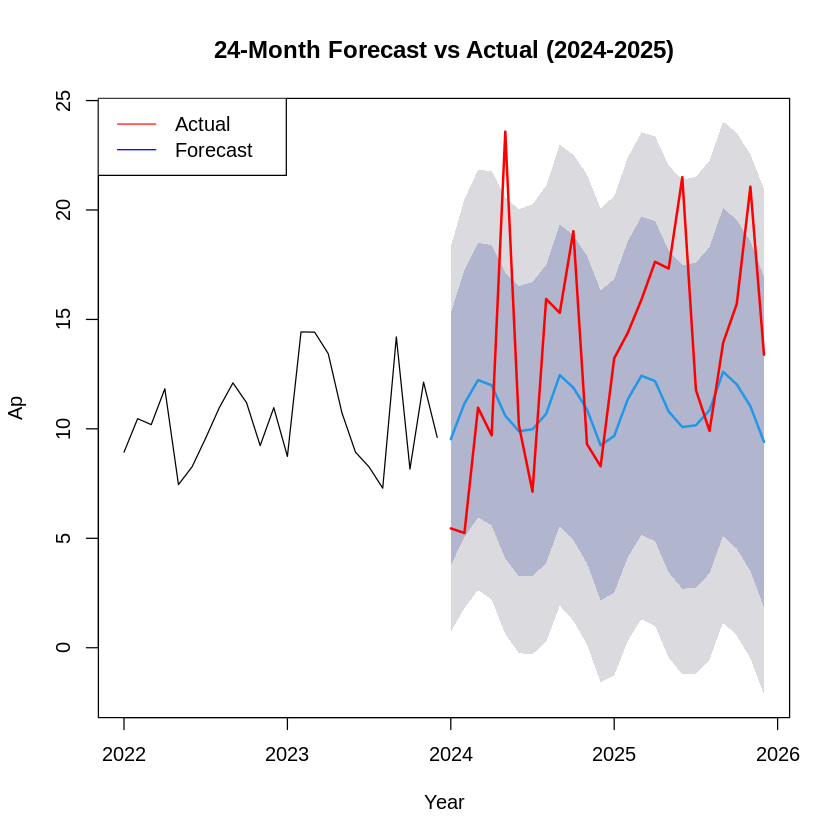

In [257]:
plot(fcast, include = 24, main = "24-Month Forecast vs Actual (2024-2025)",
     xlab = "Year", ylab = "Ap")
lines(ts_test, col = "red", lwd = 2)
legend("topleft", legend = c("Actual", "Forecast"),
       col = c("red", "blue"), lty = 1)

**Observations :**
- The actual values stays within the 95% CI (light grey).
- The forecast stays relatively flat around 10-12 which is the long term mean of the series, and this is the expected behavior for SARIMA when forecasting beyond the immediate seasonal pattern.
- The model can't predict the individual spikes as these are related to other factors which is beyond the scope of linear time series models.


In [258]:
accuracy(fcast, ts_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.1430202,4.494163,3.128092,-10.385797,25.11329,0.6540234,-0.002847069,NA
Test set,2.6123735,5.390532,4.270421,6.721004,31.80856,0.8928623,0.171514126,0.9093873


**Observations :**
- **MAE** and **RMSE** are slightly higher on the test than the training set ⇒ no overfitting.
- The increase in **MAPE** indicates the decrease in the accuracy from train to test set but still fall within the acceptable range (due to outlier spikes).
- **MASE** < 1 & **Theil's U** < 1  ⇒ the model outperforms the naïve forecasting.


# Discussion and Conclusion
- **Model diagnosis :**
the selected model SARIMA passed the most critical diagnostic (Ljung-Box test) confirming that residuals are white noise with no remaining autocorrelation. The runtest failed, suggesting a mild non-random structure likely caused by the irregular solar cycles. Normality is violated due to extreme storm spikes, which is a known limitation of linear models.


- **Model forecasting :**
the model forecasts the monthly Ap index 24 months ahead with good results confirming that the model outperforms the naïve forecasting. The actual values remain within the 95% CI, indicating a stable model behavior without overfitting.


- **Limitations :**
The model can't predict individual geomagnetic storm spikes as these are driven by other unpredictable factors such as solar wind and coronal mass ejections, which is beyond the scope of linear time models. Past values alone are not sufficient to fully explain the geomagnetic activity.


- **Conclusion :**
The project successfully modeled the 76 years of monthly geomagnetic activity using SARIMA(2,0,1)(1,0,1)[12], which captures the long-term mean behavior of the Ap index and demonstrates genuine predictions that outperformed auto.arima, while acknowledging the inherent unpredictability of extreme geomagnetic storms.